# Classification: XGBoost (Gradient Boosted Trees)

This notebook builds a survival classifier on the [Titanic dataset](https://www.kaggle.com/c/titanic) using **XGBoost** -- a **boosting** ensemble of trees, in contrast to the **bagging** ensemble (Random Forest) from the previous notebook.

Same pipeline, different ensemble strategy:
1. Get the data
2. Profile the data
3. Clean the data
4. Transform the data (encode categoricals -- no scaling needed for trees)
5. Split into train / validation / test
6. Build the model: **XGBoost (gradient boosting)**
7. **Bagging vs. boosting** -- watch trees get added *sequentially*, each correcting the previous ensemble's mistakes
8. Early stopping (boosting's own built-in overfitting guard)
9. Tune `learning_rate`, `max_depth`, and `n_estimators` using the validation set
10. Final evaluation on the held-out test set
11. Feature importances -- and a 3-way comparison: single tree vs. Random Forest vs. XGBoost
12. Inference on a new, unseen passenger
13. Save the model

## 0. Install & Import Libraries

In [1]:
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve,
)
from xgboost import XGBClassifier
import joblib

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries loaded.")


Libraries loaded.


## 1. Get the Data

Loading the dataset from a local cache under `data/` if it exists; otherwise downloading it from the public source below and saving a local copy for next time:

`https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`

Each row is one passenger; the target column is `Survived` (`0` = died, `1` = survived).

In [2]:
DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
DATA_DIR = "data"
LOCAL_PATH = os.path.join(DATA_DIR, "titanic.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_PATH):
    print(f"Loading data from local cache: {LOCAL_PATH}")
    df_raw = pd.read_csv(LOCAL_PATH)
else:
    print(f"Local file not found. Downloading from {DATA_URL} ...")
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(LOCAL_PATH, index=False)
    print(f"Saved local copy to: {LOCAL_PATH}")

print("Shape:", df_raw.shape)
df_raw.head()


Local file not found. Downloading from https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv ...
Saved local copy to: data/titanic.csv
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Profile the Data

In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
print("Survival distribution:")
print(df_raw["Survived"].value_counts(normalize=True).rename("proportion"))

print("\nNull count per column:")
print(df_raw.isna().sum())


Survival distribution:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Null count per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


`Age` has a lot of missing values, `Cabin` is missing for most passengers, and `Embarked` is missing for a couple. `PassengerId`, `Name`, and `Ticket` are unique/near-unique identifiers with no real predictive value, so they get dropped.

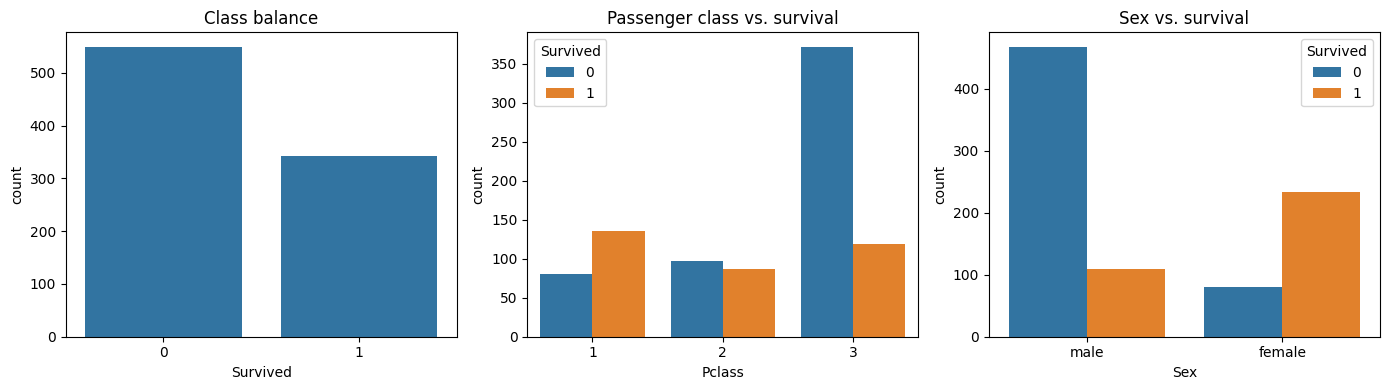

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df_raw, x="Survived", ax=axes[0])
axes[0].set_title("Class balance")

sns.countplot(data=df_raw, x="Pclass", hue="Survived", ax=axes[1])
axes[1].set_title("Passenger class vs. survival")

sns.countplot(data=df_raw, x="Sex", hue="Survived", ax=axes[2])
axes[2].set_title("Sex vs. survival")

plt.tight_layout()
plt.show()


## 3. Clean the Data

Same cleaning as the previous two notebooks:
1. Check for **true duplicates first**, while unique identifiers (`PassengerId`, `Name`, `Ticket`) are still present -- checking after dropping them would flag coincidental feature matches as false-positive "duplicates".
2. Drop `PassengerId`, `Name`, `Ticket` (identifiers) and `Cabin` (too sparse -- missing for ~77% of passengers).
3. `Age` and `Embarked` missing values are left as-is here and imputed later in the transform step (fit on train only).

In [6]:
df = df_raw.copy()

# 1. Check for true duplicate passengers FIRST, before dropping identifier columns
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} true duplicate rows -> {len(df)} rows remaining")

# 2. Drop identifier / low-value columns
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

print("\nRemaining missing values (to be imputed later, fit on train only):")
print(df.isna().sum()[df.isna().sum() > 0])


Dropped 0 true duplicate rows -> 891 rows remaining

Remaining missing values (to be imputed later, fit on train only):
Age         177
Embarked      2
dtype: int64


## 4. Transform the Data: Encode Categoricals

Like the other tree models, XGBoost doesn't need feature scaling. We still **encode categoricals** (`Sex`, `Embarked`) and **impute missing values** (`Age`, `Embarked`) -- note XGBoost can actually handle `NaN` natively and learn a default split direction for missing values, but we keep the same imputation pipeline here so all three notebooks (tree / forest / boosting) are directly comparable on identical inputs.

In [7]:
target_col = "Survived"
feature_cols = [c for c in df.columns if c != target_col]
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in feature_cols if c not in numeric_features]

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)


Numeric features    : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical features: ['Sex', 'Embarked']


In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Split into Train / Validation / Test

In [9]:
X = df[numeric_features + categorical_features]
y = df[target_col]

TEST_SIZE = 0.2
VAL_SIZE = 0.1

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y,
)

val_fraction_of_temp = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_fraction_of_temp, random_state=SEED, stratify=y_temp,
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (623, 7), Val: (89, 7), Test: (179, 7)


In [10]:
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

feature_names_out = preprocessor.get_feature_names_out()
print("Processed feature count:", len(feature_names_out))
print(feature_names_out)


Processed feature count: 10
['num__Pclass' 'num__Age' 'num__SibSp' 'num__Parch' 'num__Fare'
 'cat__Sex_female' 'cat__Sex_male' 'cat__Embarked_C' 'cat__Embarked_Q'
 'cat__Embarked_S']


## 6. Build the Model: XGBoost (Gradient Boosting)

**Bagging vs. boosting -- the key conceptual difference from the previous two notebooks:**

- A Random **Forest** (bagging) trains many trees **independently and in parallel**, each on a random bootstrap sample, then averages their votes. Every tree is trying to solve the *same* problem from a slightly different data sample; averaging cancels out each tree's individual noise.
- **XGBoost** (boosting) trains trees **sequentially**. Tree 1 makes predictions; tree 2 is trained specifically to correct tree 1's *errors* (technically, the negative gradient of the loss function -- hence "gradient boosting"); tree 3 corrects what's still wrong after trees 1+2; and so on. Each new tree depends on every tree that came before it.

This means boosting trees are typically kept **shallow** (`max_depth` of 3-6, "weak learners") -- the power comes from *many* weak trees correcting each other in sequence, not from any single deep tree. This is the opposite intuition from bagging, where individual trees can (and often should) be deep.

In [11]:
baseline_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="logloss",
)
baseline_xgb.fit(X_train_proc, y_train)

train_preds = baseline_xgb.predict(X_train_proc)
val_preds = baseline_xgb.predict(X_val_proc)

print("Baseline XGB train accuracy     :", round(accuracy_score(y_train, train_preds), 4))
print("Baseline XGB validation accuracy:", round(accuracy_score(y_val, val_preds), 4))


Baseline XGB train accuracy     : 0.9085
Baseline XGB validation accuracy: 0.8876


## 7. Watching Boosting Learn, Round by Round

Because each tree is added sequentially to correct the ensemble's current errors, we can literally plot the training/validation loss **after each round** and watch the model improve -- something a bagging forest doesn't really have (its trees don't depend on each other, so there's no natural "round-by-round" story). This uses `eval_set` to track loss (`logloss`) at every boosting round.

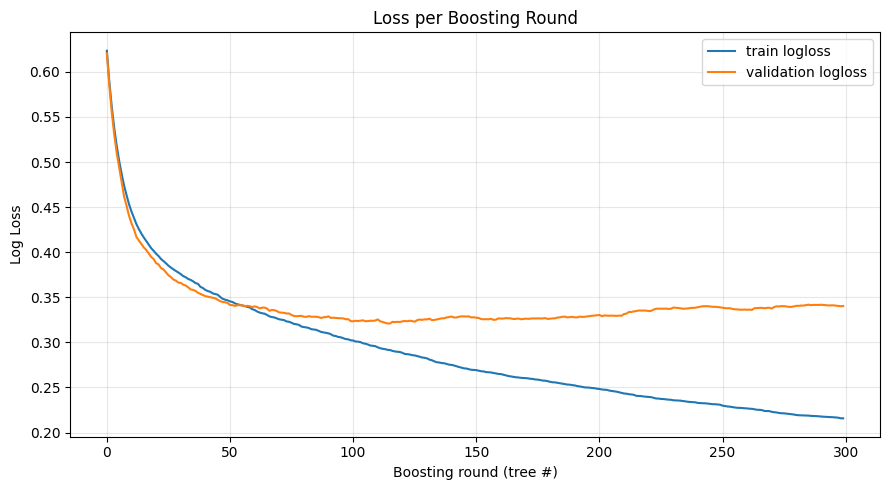

Validation logloss keeps improving until round 114, then flattens -- adding trees past that point risks overfitting.


In [12]:
eval_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="logloss",
)
eval_model.fit(
    X_train_proc, y_train,
    eval_set=[(X_train_proc, y_train), (X_val_proc, y_val)],
    verbose=False,
)

evals_result = eval_model.evals_result()
train_logloss = evals_result["validation_0"]["logloss"]
val_logloss = evals_result["validation_1"]["logloss"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_logloss, label="train logloss")
ax.plot(val_logloss, label="validation logloss")
ax.set_xlabel("Boosting round (tree #)")
ax.set_ylabel("Log Loss")
ax.set_title("Loss per Boosting Round")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_round = int(np.argmin(val_logloss))
print(f"Validation logloss keeps improving until round {best_round}, then {'flattens' if val_logloss[best_round] <= min(val_logloss[best_round:]) else "increases"} -- adding trees past that point risks overfitting.")


## 8. Early Stopping

Rather than guessing `n_estimators` up front, boosting has its own natural, built-in overfitting guard: **early stopping**. Keep adding trees as long as validation loss keeps improving; stop once it hasn't improved for a set number of rounds (`early_stopping_rounds`), and automatically roll back to the best round seen. This is boosting's version of the "elbow" logic used for `k` in KNN and `n_estimators`/`max_depth` in the forest -- except here it's automatic and doesn't require a manual sweep.

In [13]:
early_stop_model = XGBClassifier(
    n_estimators=500,          # a generous ceiling -- early stopping will cut this short
    max_depth=3,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="logloss",
    early_stopping_rounds=20,
)
early_stop_model.fit(
    X_train_proc, y_train,
    eval_set=[(X_val_proc, y_val)],
    verbose=False,
)

print("Best boosting round (0-indexed):", early_stop_model.best_iteration)
print("Trees actually used            :", early_stop_model.best_iteration + 1, "out of the 500 allowed")
print("Validation accuracy at best round:", round(accuracy_score(y_val, early_stop_model.predict(X_val_proc)), 4))


Best boosting round (0-indexed): 114
Trees actually used            : 115 out of the 500 allowed
Validation accuracy at best round: 0.8876


## 9. Tune `learning_rate`, `max_depth`, and `n_estimators`

`learning_rate` (aka "shrinkage") scales down each new tree's contribution to the ensemble -- a smaller value means each tree corrects the errors more cautiously, needing more rounds to converge but generally generalizing better. There's a direct trade-off between `learning_rate` and how many trees are needed:
- **high learning rate** -> converges fast, but risks overshooting / overfitting
- **low learning rate** -> needs more trees (more `n_estimators`), but usually more robust

We use early stopping again here so we don't have to separately tune `n_estimators` for every `learning_rate`/`max_depth` combination -- it finds the right number of trees automatically for each setting.

In [14]:
learning_rates = [0.3, 0.1, 0.05, 0.01]
max_depths = [2, 3, 4, 6]

tuning_results = []

for lr in learning_rates:
    for depth in max_depths:
        model = XGBClassifier(
            n_estimators=1000,
            max_depth=depth,
            learning_rate=lr,
            random_state=SEED,
            n_jobs=-1,
            eval_metric="logloss",
            early_stopping_rounds=20,
        )
        model.fit(X_train_proc, y_train, eval_set=[(X_val_proc, y_val)], verbose=False)

        val_acc = accuracy_score(y_val, model.predict(X_val_proc))
        tuning_results.append({
            "learning_rate": lr,
            "max_depth": depth,
            "best_n_trees": model.best_iteration + 1,
            "val_acc": val_acc,
        })

tuning_df = pd.DataFrame(tuning_results).sort_values("val_acc", ascending=False).reset_index(drop=True)
tuning_df


,learning_rate,max_depth,best_n_trees,val_acc
0,0.01,4,756,0.898876
1,0.05,4,138,0.898876
2,0.30,3,41,0.887640
3,0.10,3,115,0.887640
4,0.05,3,251,0.887640
5,0.01,3,836,0.887640
6,0.10,4,102,0.887640
7,0.30,2,53,0.876404
8,0.01,2,999,0.865169
9,0.10,2,207,0.865169


In [15]:
best_config = tuning_df.iloc[0]
BEST_LR = best_config["learning_rate"]
BEST_DEPTH = int(best_config["max_depth"])
BEST_N_TREES = int(best_config["best_n_trees"])

print(f"Selected learning_rate: {BEST_LR}")
print(f"Selected max_depth    : {BEST_DEPTH}")
print(f"Selected n_estimators : {BEST_N_TREES} (from early stopping)")


Selected learning_rate: 0.01
Selected max_depth    : 4
Selected n_estimators : 756 (from early stopping)


## 10. Final Evaluation on the Held-Out Test Set

Refit on train with the selected config (fixed `n_estimators` from early stopping, so the test set is never used to decide how many trees to build), then evaluate once on test.

In [16]:
final_xgb = XGBClassifier(
    n_estimators=BEST_N_TREES,
    max_depth=BEST_DEPTH,
    learning_rate=BEST_LR,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="logloss",
)
final_xgb.fit(X_train_proc, y_train)

test_preds = final_xgb.predict(X_test_proc)
test_probs = final_xgb.predict_proba(X_test_proc)[:, 1]

print("Test accuracy :", round(accuracy_score(y_test, test_preds), 4))
print("Test precision:", round(precision_score(y_test, test_preds), 4))
print("Test recall   :", round(recall_score(y_test, test_preds), 4))
print("Test F1       :", round(f1_score(y_test, test_preds), 4))
print("Test ROC AUC  :", round(roc_auc_score(y_test, test_probs), 4))
print()
print(classification_report(y_test, test_preds, target_names=["died", "survived"]))


Test accuracy : 0.7933
Test precision: 0.7759
Test recall   : 0.6522
Test F1       : 0.7087
Test ROC AUC  : 0.8082

              precision    recall  f1-score   support

        died       0.80      0.88      0.84       110
    survived       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



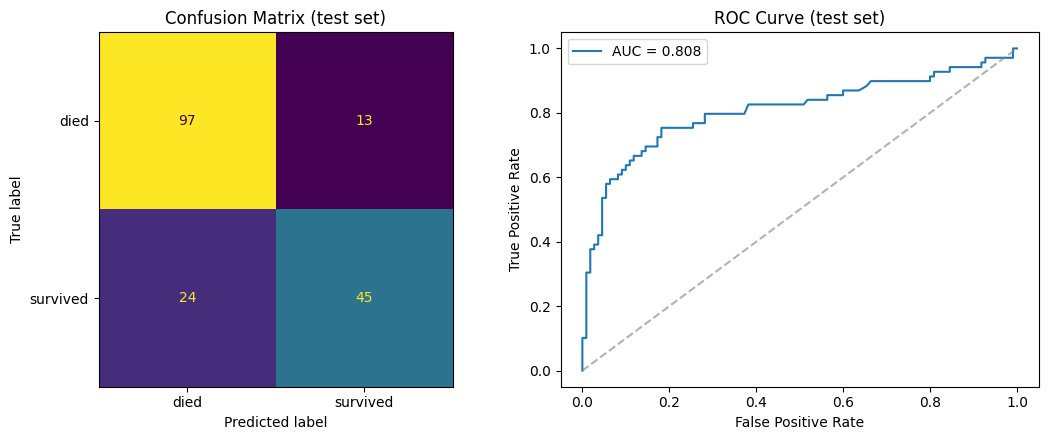

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["died", "survived"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (test set)")

fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_probs):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.6)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (test set)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Feature Importances: Single Tree vs. Random Forest vs. XGBoost

XGBoost's default importance is also impurity/gain-based, similar in spirit to the tree and forest importances -- but computed from many *shallow, sequentially-dependent* trees rather than deep independent ones, so the ranking can shift meaningfully.

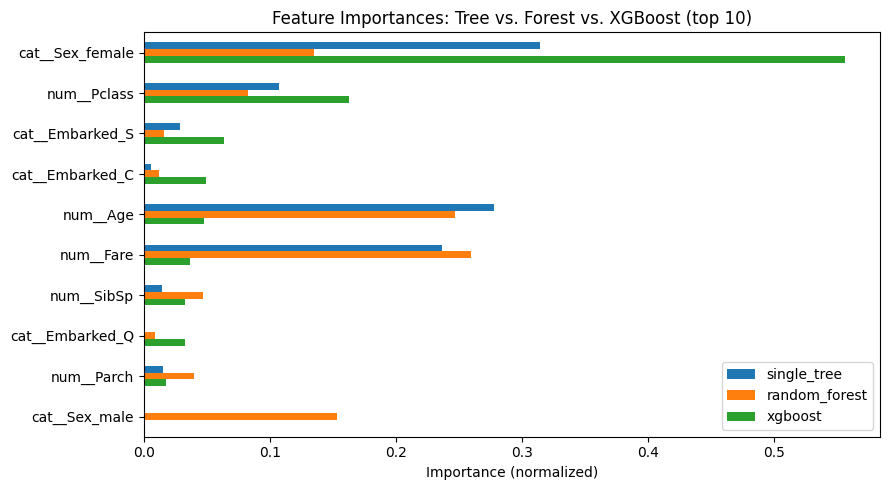

,single_tree,random_forest,xgboost
cat__Sex_female,0.314556,0.134585,0.556148
num__Pclass,0.107116,0.082765,0.162718
cat__Embarked_S,0.028474,0.016162,0.063684
cat__Embarked_C,0.005939,0.011634,0.049331
num__Age,0.277383,0.246875,0.047906
num__Fare,0.236778,0.259216,0.036725
num__SibSp,0.014636,0.046921,0.032807
cat__Embarked_Q,0.000000,0.009039,0.032766
num__Parch,0.015118,0.039439,0.017914
cat__Sex_male,0.000000,0.153364,0.000000


In [18]:
single_tree = DecisionTreeClassifier(random_state=SEED)
single_tree.fit(X_train_proc, y_train)

rf_model = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_proc, y_train)

importances_tree = pd.Series(single_tree.feature_importances_, index=feature_names_out, name="single_tree")
importances_forest = pd.Series(rf_model.feature_importances_, index=feature_names_out, name="random_forest")
importances_xgb = pd.Series(final_xgb.feature_importances_, index=feature_names_out, name="xgboost")

comparison = pd.concat([importances_tree, importances_forest, importances_xgb], axis=1).sort_values("xgboost", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
comparison.head(10).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Importance (normalized)")
ax.set_title("Feature Importances: Tree vs. Forest vs. XGBoost (top 10)")
plt.tight_layout()
plt.show()

comparison


## 12. Inference on a New, Unseen Passenger

In [19]:
def predict_survival(raw_features: dict, model, preprocessor):
    input_df = pd.DataFrame([raw_features])
    input_proc = preprocessor.transform(input_df)
    pred = model.predict(input_proc)[0]
    prob = model.predict_proba(input_proc)[0, 1]
    return pred, prob


example_passenger = {
    "Pclass": 3,
    "Sex": "male",
    "Age": 22,
    "SibSp": 1,
    "Parch": 0,
    "Fare": 7.25,
    "Embarked": "S",
}

pred, prob = predict_survival(example_passenger, final_xgb, preprocessor)
print(f"Predicted: {'survived' if pred == 1 else 'died'} (P(survived) = {prob:.3f})")


Predicted: died (P(survived) = 0.074)


## 13. Save the Model (optional)

In [20]:
joblib.dump({"model": final_xgb, "preprocessor": preprocessor}, "titanic_xgb_classifier.joblib")
print("Model + preprocessor saved to titanic_xgb_classifier.joblib")

# To reload later:
# bundle = joblib.load("titanic_xgb_classifier.joblib")
# final_xgb, preprocessor = bundle["model"], bundle["preprocessor"]


Model + preprocessor saved to titanic_xgb_classifier.joblib
